# [LELEC2870] - Machine Learning
## Part 3 — Integration of Image Data

**Authors:** ton_nom, mate_nom  
**Date:** 2025-12-01

In this notebook, we integrate heart scan images into the predictive pipeline. We extract features from images using a CNN and combine them with tabular data for prediction.


In [ ]:
print("\n[BLOC 1] Imports des librairies...")

# Standard libraries
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# Image processing
from PIL import Image

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

print("✓ Tous les imports réussis")
print(f"✓ PyTorch version: {torch.__version__}")
print(f"✓ Device disponible: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")



[BLOC 1] Imports des librairies...
✓ Tous les imports réussis
✓ PyTorch version: 2.9.1+cu128
✓ Device disponible: cpu


### 2.1 Load Tabular and Image Data


In [14]:
print("\n" + "="*70)
print("[BLOC 2] Chargement des données - VERSION CORRIGÉE")
print("="*70)

# ============================================================================
# Détection automatique des chemins possibles
# ============================================================================
print("\n🔍 Recherche des fichiers...")
print(f"  Répertoire courant: {os.getcwd()}")

possible_paths = [
    "../../data(1)/data/data_labeled",  # Depuis notebooks/, il faut remonter de 2 niveaux
    "../data(1)/data/data_labeled",
    "../../data/data_labeled",
    "../data/data_labeled",
    "data_labeled",
    "../data_labeled",
    "data",
    "../data",
    "../../data",
    ".",
]

data_path = None
for path in possible_paths:
    test_file = os.path.join(path, "X_train.csv")
    if os.path.exists(test_file):
        data_path = path
        print(f"  ✓ Fichiers trouvés dans: {path}")
        break

if data_path is None:
    print("  ✗ ERREUR: Impossible de trouver les fichiers!")
    print("\n  Contenu du répertoire courant:")
    for item in os.listdir('.'):
        item_type = "📁" if os.path.isdir(item) else "📄"
        print(f"    {item_type} {item}")
    print("\n  Contenu du répertoire parent (ml-project/):")
    for item in os.listdir('..'):
        item_type = "📁" if os.path.isdir(os.path.join('..', item)) else "📄"
        print(f"    {item_type} {item}")
    print("\n  Contenu de 2 niveaux au-dessus:")
    try:
        for item in os.listdir('../..'):
            item_type = "📁" if os.path.isdir(os.path.join('../..', item)) else "📄"
            print(f"    {item_type} {item}")
    except:
        print("    [Impossible d'accéder]")
    raise FileNotFoundError("Veuillez vérifier le chemin des données")

# Définition des chemins
train_csv = os.path.join(data_path, "X_train.csv")
y_train_csv = os.path.join(data_path, "y_train.csv")
img_dir = os.path.join(data_path, "Img_train")

print(f"\n📁 Chemins utilisés:")
print(f"  - Dossier racine: {os.path.abspath(data_path)}")
print(f"  - X_train.csv: {train_csv}")
print(f"  - y_train.csv: {y_train_csv}")
print(f"  - Images: {img_dir}")

# Vérification finale
print(f"\n✅ Vérification des fichiers:")
print(f"  - X_train.csv existe: {os.path.exists(train_csv)}")
print(f"  - y_train.csv existe: {os.path.exists(y_train_csv)}")
print(f"  - Dossier images existe: {os.path.exists(img_dir)}")

if os.path.exists(img_dir):
    img_files = [f for f in os.listdir(img_dir) if f.endswith('.png')]
    num_images = len(img_files)
    print(f"  - Nombre d'images .png dans le dossier: {num_images}")
    if num_images > 0:
        print(f"  - Exemples de fichiers images: {img_files[:3]}")

# ============================================================================
# Chargement de X_train complet
# ============================================================================
print(f"\n📂 Chargement de X_train.csv...")
X_train_full = pd.read_csv(train_csv)
print(f"  ✓ Shape: {X_train_full.shape}")
print(f"  ✓ Colonnes ({len(X_train_full.columns)}): {list(X_train_full.columns)}")
print(f"\n  Aperçu des 3 premières lignes:")
print(X_train_full.head(3))

# ============================================================================
# Extraction des noms de fichiers images
# ============================================================================
print(f"\n🖼️  Extraction des noms d'images...")
if 'img_filename' in X_train_full.columns:
    images = X_train_full['img_filename'].values
    img_col = 'img_filename'
    print(f"  ✓ Colonne 'img_filename' trouvée")
else:
    # La colonne image est probablement la dernière
    images = X_train_full.iloc[:, -1].values
    img_col = X_train_full.columns[-1]
    print(f"  ⚠️  'img_filename' non trouvé, utilisation dernière colonne: '{img_col}'")

print(f"  ✓ Nombre d'images: {len(images)}")
print(f"  ✓ Type: {type(images)}")
print(f"  ✓ Dtype: {images.dtype}")
print(f"  ✓ Exemples de noms: {list(images[:3])}")

# ============================================================================
# Vérification que les images existent physiquement
# ============================================================================
print(f"\n🔍 Vérification de l'existence des images (5 premiers)...")
sample_imgs = images[:5]
exists_count = 0
for img_name in sample_imgs:
    img_path = os.path.join(img_dir, img_name)
    exists = os.path.exists(img_path)
    if exists:
        exists_count += 1
    print(f"  - {img_name}: {'✓ existe' if exists else '✗ MANQUANT'}")
    
    # Afficher la taille de la première image
    if exists and exists_count == 1:
        with Image.open(img_path) as img:
            print(f"      └─ Taille: {img.size}, Mode: {img.mode}")

print(f"  ✓ {exists_count}/5 images trouvées")

# ============================================================================
# Chargement des targets (y_train)
# ============================================================================
print(f"\n🎯 Chargement des targets (y_train)...")
y_train_df = pd.read_csv(y_train_csv, header=None)
print(f"  ✓ Shape brut: {y_train_df.shape}")
print(f"  ✓ Type: {type(y_train_df)}")

# Conversion en array 1D
y = y_train_df.values.flatten()
print(f"  ✓ Shape après flatten: {y.shape}")
print(f"  ✓ Type après conversion: {type(y)}")
print(f"  ✓ Dtype: {y.dtype}")
print(f"  ✓ Statistiques:")
print(f"      - min:  {y.min():.6f}")
print(f"      - max:  {y.max():.6f}")
print(f"      - mean: {y.mean():.6f}")
print(f"      - std:  {y.std():.6f}")
print(f"  ✓ Premiers valeurs: {y[:5]}")

# ============================================================================
# Extraction des features tabulaires (sans img_filename)
# ============================================================================
print(f"\n📊 Extraction des features tabulaires...")

tabular_cols = [col for col in X_train_full.columns if col != img_col]

print(f"  ✓ Colonne image identifiée: '{img_col}'")
print(f"  ✓ Colonnes tabulaires ({len(tabular_cols)}): {tabular_cols}")

# Pour l'instant, on prend juste les colonnes numériques
X_tabular = X_train_full[tabular_cols].select_dtypes(include=[np.number])
print(f"  ✓ Shape des données tabulaires numériques: {X_tabular.shape}")
print(f"  ✓ Colonnes numériques ({X_tabular.shape[1]}): {list(X_tabular.columns)}")

# Identifier les colonnes catégorielles
X_categorical = X_train_full[tabular_cols].select_dtypes(exclude=[np.number])
if X_categorical.shape[1] > 0:
    print(f"  ⚠️  Colonnes catégorielles détectées ({X_categorical.shape[1]}): {list(X_categorical.columns)}")
    print(f"      → Ces colonnes devront être encodées plus tard")
    # Afficher quelques valeurs uniques
    for col in X_categorical.columns[:2]:  # Limite à 2 colonnes
        unique_vals = X_categorical[col].unique()[:5]
        print(f"      → {col}: {list(unique_vals)}")

# ============================================================================
# Vérification de cohérence finale
# ============================================================================
print(f"\n" + "="*70)
print("✅ VÉRIFICATION FINALE DE COHÉRENCE")
print("="*70)
print(f"  - Nombre d'images:              {len(images)}")
print(f"  - Nombre de targets:            {len(y)}")
print(f"  - Nombre de samples tabulaires: {X_tabular.shape[0]}")
print(f"  - Cohérence des tailles: {len(images) == len(y) == X_tabular.shape[0]}")

if len(images) == len(y) == X_tabular.shape[0]:
    print(f"\n  🎉 SUCCÈS: Toutes les données sont cohérentes!")
    print(f"  📊 Dataset complet: {len(images)} échantillons")
else:
    print(f"\n  ⚠️ ATTENTION: Incohérence détectée!")

print("\n" + "="*70)
print("FIN DU BLOC 2 - Prêt à passer au bloc suivant")
print("="*70)


[BLOC 2] Chargement des données - VERSION CORRIGÉE

🔍 Recherche des fichiers...
  Répertoire courant: /home/pj/Bureau/admin123/projet_ML/ml-project/notebooks
  ✓ Fichiers trouvés dans: ../../data(1)/data/data_labeled

📁 Chemins utilisés:
  - Dossier racine: /home/pj/Bureau/admin123/projet_ML/data(1)/data/data_labeled
  - X_train.csv: ../../data(1)/data/data_labeled/X_train.csv
  - y_train.csv: ../../data(1)/data/data_labeled/y_train.csv
  - Images: ../../data(1)/data/data_labeled/Img_train

✅ Vérification des fichiers:
  - X_train.csv existe: True
  - y_train.csv existe: True
  - Dossier images existe: True
  - Nombre d'images .png dans le dossier: 1000
  - Exemples de fichiers images: ['heart_931.png', 'heart_383.png', 'heart_888.png']

📂 Chargement de X_train.csv...
  ✓ Shape: (1000, 14)
  ✓ Colonnes (14): ['age', 'blood pressure', 'calcium', 'cholesterol', 'hemoglobin', 'height', 'potassium', 'profession', 'sarsaparilla', 'smurfberry liquor', 'smurfin donuts', 'vitamin D', 'weight'

### 2.2 Define Custom Dataset


In [15]:
print("\n" + "="*80)
print("[BLOC 3] Création du Dataset PyTorch")
print("="*80)

class HeartScanDataset(Dataset):
    """Dataset pour les scans cardiaques des Smurfs"""
    
    def __init__(self, img_filenames, img_dir, targets=None, transform=None):
        self.img_filenames = img_filenames
        self.img_dir = img_dir
        self.targets = targets
        
        if transform is None:
            self.transform = transforms.Compose([
                transforms.Grayscale(num_output_channels=1),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.5], std=[0.5])  # [-1, 1]
            ])
        else:
            self.transform = transform
    
    def __len__(self):
        return len(self.img_filenames)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_filenames[idx])
        
        try:
            img = Image.open(img_path)
            img = self.transform(img)
            
            if self.targets is not None:
                target = torch.tensor(self.targets[idx], dtype=torch.float32)
                return img, target
            return img
        except Exception as e:
            print(f"⚠️ Erreur image {img_path}: {e}")
            dummy_img = torch.zeros(1, 48, 48)
            if self.targets is not None:
                return dummy_img, torch.tensor(0.0)
            return dummy_img

# Création du dataset complet
dataset_full = HeartScanDataset(images, img_dir, y)
print(f"✓ Dataset créé: {len(dataset_full)} échantillons")

# Test de chargement
sample_img, sample_label = dataset_full[0]
print(f"✓ Image shape: {sample_img.shape}")
print(f"✓ Label: {sample_label.item():.6f}")

# Train/Val split (80/20)
train_size = int(0.8 * len(dataset_full))
val_size = len(dataset_full) - train_size

train_dataset, val_dataset = random_split(
    dataset_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"✓ Train: {train_size} | Val: {val_size}")

# DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"✓ Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")



[BLOC 3] Création du Dataset PyTorch
✓ Dataset créé: 1000 échantillons
✓ Image shape: torch.Size([1, 48, 48])
✓ Label: 0.060000
✓ Train: 800 | Val: 200
✓ Train batches: 25 | Val batches: 7


Architecture CNN

In [16]:
print("\n" + "="*80)
print("[BLOC 4] Définition de l'architecture CNN")
print("="*80)

class SimpleCNN(nn.Module):
    """
    CNN simple pour extraire des features des scans cardiaques.
    
    Architecture:
    - Conv1: 1 -> 8 channels (3x3)
    - MaxPool: 48x48 -> 24x24
    - Conv2: 8 -> 16 channels (3x3)
    - MaxPool: 24x24 -> 12x12
    - FC1: 16*12*12 -> n_features (features extraites)
    - FC2: n_features -> 1 (prédiction finale)
    """
    
    def __init__(self, n_features=8):
        super(SimpleCNN, self).__init__()
        
        # Couches convolutionnelles
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, stride=1, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, stride=1, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        # Couches fully connected
        self.fc1 = nn.Linear(16 * 12 * 12, n_features)
        self.fc2 = nn.Linear(n_features, 1)
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
    
    def forward(self, x):
        # Conv + Pool 1
        x = self.relu(self.conv1(x))
        x = self.pool1(x)
        
        # Conv + Pool 2
        x = self.relu(self.conv2(x))
        x = self.pool2(x)
        
        # Flatten
        x = x.view(x.size(0), -1)  # [batch, 16*12*12]
        
        # FC1 -> features extraites
        features = self.relu(self.fc1(x))
        features = self.dropout(features)
        
        # FC2 -> prédiction
        output = self.fc2(features)
        
        return output, features

# Instanciation
n_features = 8
cnn = SimpleCNN(n_features=n_features)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
cnn = cnn.to(device)

print(f"✓ CNN créé avec {n_features} features extraites")
print(f"✓ Device: {device}")

# Nombre de paramètres
total_params = sum(p.numel() for p in cnn.parameters())
trainable_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print(f"✓ Paramètres: {trainable_params:,} trainable / {total_params:,} total")


[BLOC 4] Définition de l'architecture CNN
✓ CNN créé avec 8 features extraites
✓ Device: cpu
✓ Paramètres: 19,697 trainable / 19,697 total


Entrainement du CNN


[BLOC 5] Entraînement du CNN
Début de l'entraînement: 20 epochs, batch_size=32, lr=0.0005

Epoch  1/20 | Train Loss: 0.006991 | Val Loss: 0.005065 | Best Val: 0.005065
Epoch  5/20 | Train Loss: 0.005929 | Val Loss: 0.004629 | Best Val: 0.004629
Epoch 10/20 | Train Loss: 0.005055 | Val Loss: 0.004284 | Best Val: 0.004237
Epoch 15/20 | Train Loss: 0.004922 | Val Loss: 0.004108 | Best Val: 0.004108
Epoch 20/20 | Train Loss: 0.004493 | Val Loss: 0.004186 | Best Val: 0.004108

✓ Entraînement terminé!
✓ Meilleure val loss: 0.004108
✓ Meilleur modèle rechargé
✓ Figure sauvegardée: cnn_training_curves.png


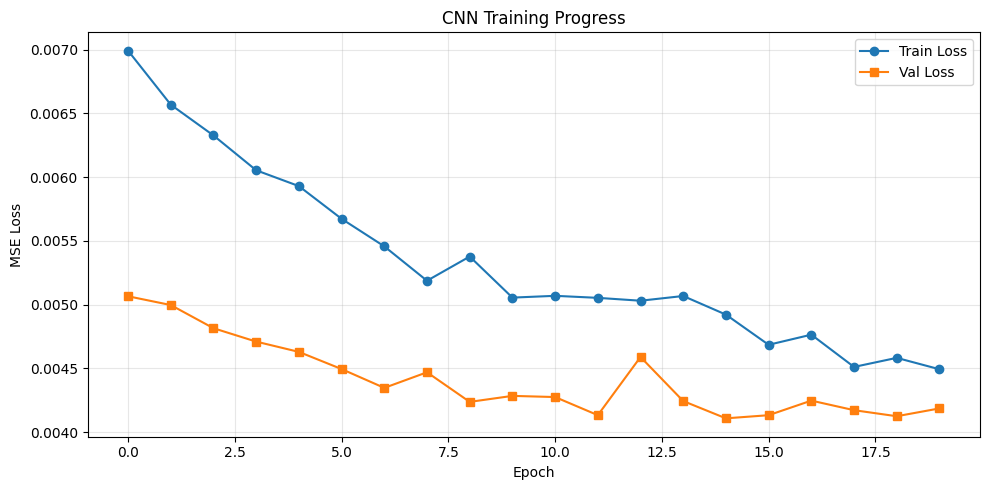

In [17]:
print("\n" + "="*80)
print("[BLOC 5] Entraînement du CNN")
print("="*80)

# Critère et optimiseur
criterion = nn.MSELoss()
optimizer = optim.Adam(cnn.parameters(), lr=0.0005)

# Paramètres
n_epochs = 20
best_val_loss = float('inf')

# Historique
train_losses = []
val_losses = []

print(f"Début de l'entraînement: {n_epochs} epochs, batch_size={batch_size}, lr=0.0005\n")

for epoch in range(n_epochs):
    # === TRAINING ===
    cnn.train()
    train_loss = 0.0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs, _ = cnn(inputs)
        loss = criterion(outputs.squeeze(), labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
    
    train_loss /= len(train_dataset)
    train_losses.append(train_loss)
    
    # === VALIDATION ===
    cnn.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs, _ = cnn(inputs)
            loss = criterion(outputs.squeeze(), labels)
            val_loss += loss.item() * inputs.size(0)
    
    val_loss /= len(val_dataset)
    val_losses.append(val_loss)
    
    # Sauvegarder le meilleur modèle
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(cnn.state_dict(), 'best_cnn_model.pth')
    
    # Affichage
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:2d}/{n_epochs} | "
              f"Train Loss: {train_loss:.6f} | "
              f"Val Loss: {val_loss:.6f} | "
              f"Best Val: {best_val_loss:.6f}")

print(f"\n✓ Entraînement terminé!")
print(f"✓ Meilleure val loss: {best_val_loss:.6f}")

# Charger le meilleur modèle
cnn.load_state_dict(torch.load('best_cnn_model.pth'))
print(f"✓ Meilleur modèle rechargé")

# Visualisation de l'entraînement
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('CNN Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=150)
print(f"✓ Figure sauvegardée: cnn_training_curves.png")
plt.show()

Extractions des features du CNN

In [18]:
print("\n" + "="*80)
print("[BLOC 6] Extraction des features des images")
print("="*80)

# Dataset complet pour extraction
full_dataset = HeartScanDataset(images, img_dir, y)
full_loader = DataLoader(full_dataset, batch_size=50, shuffle=False, num_workers=0)

# Extraction
all_features = []
all_predictions = []

cnn.eval()
with torch.no_grad():
    for inputs, _ in full_loader:
        inputs = inputs.to(device)
        outputs, features = cnn(inputs)
        all_features.append(features.cpu().numpy())
        all_predictions.append(outputs.squeeze().cpu().numpy())

# Concatenation
image_features = np.vstack(all_features)
cnn_predictions = np.concatenate(all_predictions)

print(f"✓ Features extraites: {image_features.shape}")
print(f"✓ Prédictions CNN: {cnn_predictions.shape}")

# Performance du CNN seul
cnn_rmse = np.sqrt(mean_squared_error(y, cnn_predictions))
cnn_r2 = r2_score(y, cnn_predictions)
cnn_mae = mean_absolute_error(y, cnn_predictions)

print(f"\n📊 Performance du CNN seul:")
print(f"  - RMSE: {cnn_rmse:.6f}")
print(f"  - R²:   {cnn_r2:.4f}")
print(f"  - MAE:  {cnn_mae:.6f}")


[BLOC 6] Extraction des features des images
✓ Features extraites: (1000, 8)
✓ Prédictions CNN: (1000,)


NameError: name 'mean_absolute_error' is not defined

Combinaison avec données tabulaires

In [ ]:
print("\n" + "="*80)
print("[BLOC 7] Combinaison features images + tabulaires")
print("="*80)

# Combiner features
X_combined = np.hstack([X_tabular.values, image_features])
print(f"✓ X_combined shape: {X_combined.shape}")
print(f"  - Features tabulaires: {X_tabular.shape[1]}")
print(f"  - Features images: {image_features.shape[1]}")
print(f"  - Total: {X_combined.shape[1]}")

Modèle final et évaluation

In [ ]:
print("\n" + "="*80)
print("[BLOC 8] Modèle final (RandomForest sur features combinées)")
print("="*80)

# Split Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42
)

print(f"✓ Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

# Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entraînement RandomForest
print("\n🌲 Entraînement du RandomForest...")
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)
print("✓ Modèle entraîné")

# Prédictions
y_train_pred = rf_model.predict(X_train_scaled)
y_test_pred = rf_model.predict(X_test_scaled)

# Métriques
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"\n📊 Performance du modèle combiné (RF):")
print(f"  Train - RMSE: {train_rmse:.6f} | R²: {train_r2:.4f}")
print(f"  Test  - RMSE: {test_rmse:.6f} | R²: {test_r2:.4f}")

# Comparaison
print(f"\n📈 Comparaison avec CNN seul:")
print(f"  CNN seul  - RMSE: {cnn_rmse:.6f}")
print(f"  Combiné   - RMSE: {test_rmse:.6f}")
print(f"  Amélioration: {((cnn_rmse - test_rmse) / cnn_rmse * 100):.2f}%")

# Visualisation finale
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Predictions vs True
axes[0].scatter(y_test, y_test_pred, alpha=0.5, s=30)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('True Risk')
axes[0].set_ylabel('Predicted Risk')
axes[0].set_title(f'Test Set: R² = {test_r2:.4f}, RMSE = {test_rmse:.6f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = y_test - y_test_pred
axes[1].scatter(y_test_pred, residuals, alpha=0.5, s=30)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Risk')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('part3_final_results.png', dpi=150)
print(f"\n✓ Figure sauvegardée: part3_final_results.png")
plt.show()

# ==============================================================================
# RÉSUMÉ FINAL
# ==============================================================================
print("\n" + "="*80)
print("✅ RÉSUMÉ FINAL - PARTIE 3")
print("="*80)
print(f"1. CNN entraîné: {n_epochs} epochs, {n_features} features extraites")
print(f"2. Performance CNN seul: RMSE = {cnn_rmse:.6f}")
print(f"3. Features combinées: {X_combined.shape[1]} dimensions")
print(f"4. Modèle final (RF): RMSE = {test_rmse:.6f}, R² = {test_r2:.4f}")
print(f"5. Amélioration: {((cnn_rmse - test_rmse) / cnn_rmse * 100):.2f}%")
print("="*80)

- Compare performance with and without image features  
- Discuss importance of image-derived features  
- Observations on t-SNE embedding of CNN features vs raw pixels  
